Using device: cuda
Generated Full Data: 101 spatial points * 601 time points = 60701 total full samples.
Generated Training Data: 6 spatial points * 601 time points = 3606 total training samples.
Starting training with phased learning rate...
Epoch [100/50000], LR: 0.001000, Train Loss (Sensor Pts): 0.366730, Full Grid MSE: 0.362226
Epoch [200/50000], LR: 0.001000, Train Loss (Sensor Pts): 0.156091, Full Grid MSE: 0.180660
Epoch [300/50000], LR: 0.001000, Train Loss (Sensor Pts): 0.112039, Full Grid MSE: 0.132199
Epoch [400/50000], LR: 0.001000, Train Loss (Sensor Pts): 0.096441, Full Grid MSE: 0.115016
Epoch [500/50000], LR: 0.001000, Train Loss (Sensor Pts): 0.085436, Full Grid MSE: 0.102174
Epoch [600/50000], LR: 0.001000, Train Loss (Sensor Pts): 0.076000, Full Grid MSE: 0.091412
Epoch [700/50000], LR: 0.001000, Train Loss (Sensor Pts): 0.068195, Full Grid MSE: 0.081942
Epoch [800/50000], LR: 0.001000, Train Loss (Sensor Pts): 0.064092, Full Grid MSE: 0.078118
Epoch [900/50000], LR

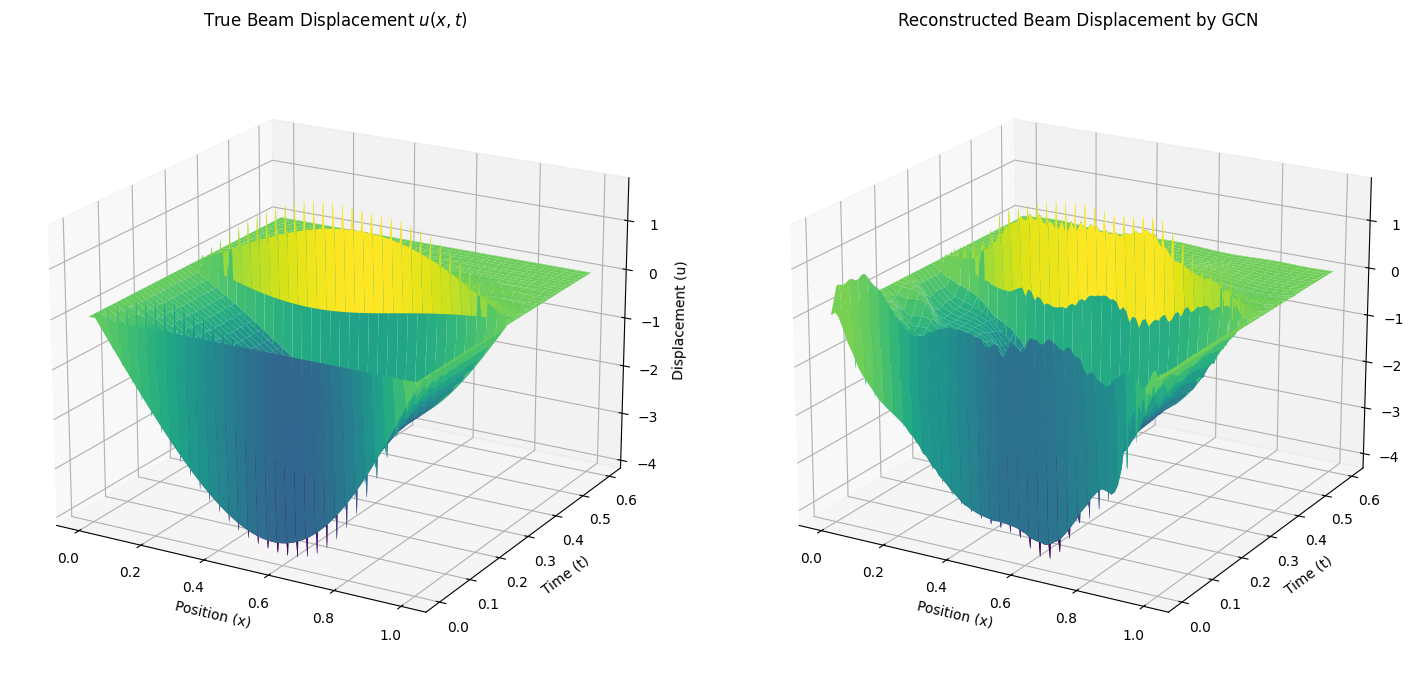

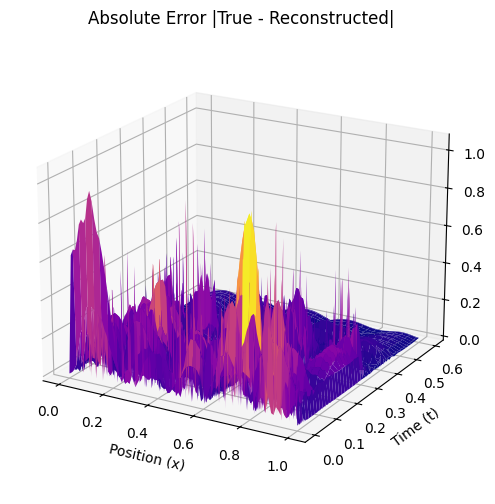

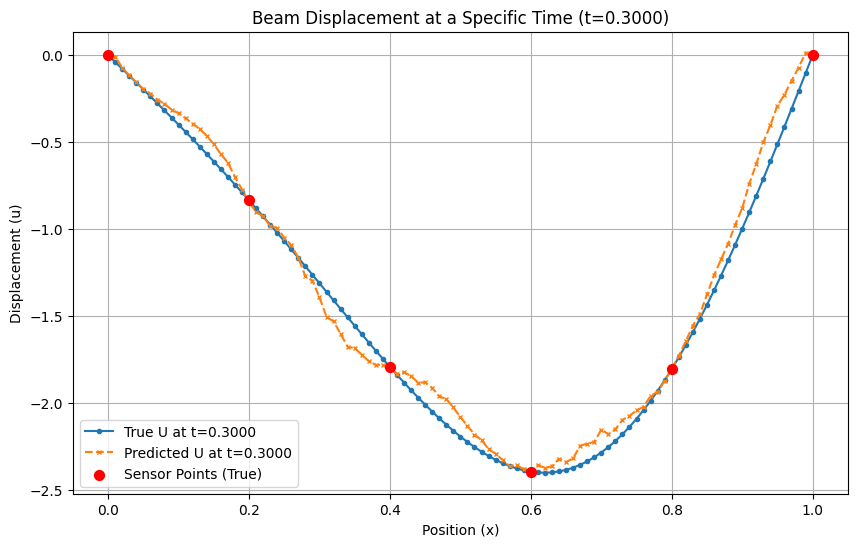

Final Full Grid MSE Loss: 0.016225


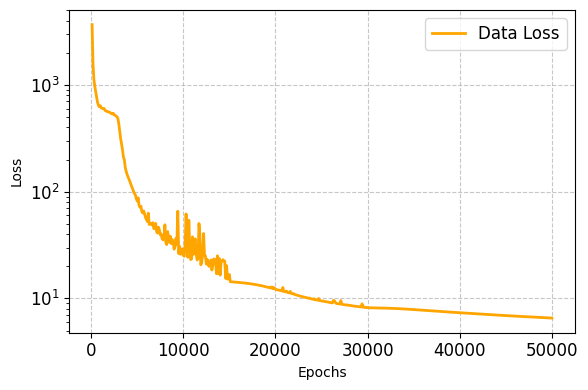

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.neighbors import NearestNeighbors
from scipy.io import loadmat 
import torch.nn.functional as F


def generate_labeled_data(mat_file="beam.mat", t_min=0.0, t_max=0.6, num_space_points=20):
    data_w = loadmat(mat_file)
    t_data = data_w["t"].flatten()[:, None] 
    x_data = data_w["x"].flatten()          
    y_data = data_w["Y"]                  
    valid = (t_data >= t_min) & (t_data <= t_max)
    t_filt = t_data[valid.flatten()]       
    y_filt = 1e5*y_data[valid.flatten(), :]    
    space_idx = np.linspace(0, len(x_data)-1, num_space_points, dtype=int)
    x_filt = x_data[space_idx]              
    y_filt_space = y_filt[:, space_idx]    
    X, T = np.meshgrid(x_filt, t_filt.flatten())
    inputs = np.hstack([X.flatten()[:,None], T.flatten()[:,None]])
    outputs = y_filt_space.flatten()[:,None]
    print(f"Generated Training Data: {len(x_filt)} spatial points * {len(t_filt)} time points = {inputs.shape[0]} total training samples.")
    return inputs.astype(np.float32), outputs.astype(np.float32), len(x_filt), len(t_filt)


def generate_labeled_data_all(mat_file="beam.mat", t_min=0.0, t_max=0.6):
    data_w = loadmat(mat_file)
    t_data = data_w["t"].flatten()[:, None]
    x_data = data_w["x"].flatten()
    y_data = data_w["Y"]
    valid = (t_data >= t_min) & (t_data <= t_max)
    t_filt = t_data[valid.flatten()]
    y_filt = 1e5*y_data[valid.flatten(), :] # (num_t_filt, num_x_full)
    X_grid, T_grid = np.meshgrid(x_data, t_filt.flatten())
    inputs = np.hstack([X_grid.flatten()[:,None], T_grid.flatten()[:,None]])
    outputs = y_filt.flatten()[:,None]
    print(f"Generated Full Data: {len(x_data)} spatial points * {len(t_filt)} time points = {inputs.shape[0]} total full samples.")
    return inputs.astype(np.float32), outputs.astype(np.float32), len(x_data), len(t_filt), X_grid, T_grid, y_filt

def build_graph_from_grid(node_coords, k_neighbors=1):
    num_nodes = node_coords.shape[0]
    nbrs = NearestNeighbors(n_neighbors=k_neighbors + 1, algorithm='kd_tree').fit(node_coords)
    distances, indices = nbrs.kneighbors(node_coords)

    edge_index = []
    for i in range(num_nodes):
        for j in range(1, k_neighbors + 1): # 跳过自身
            neighbor_node = indices[i][j]
            edge_index.append([i, neighbor_node])
            edge_index.append([neighbor_node, i]) # 无向图

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_index = torch.unique(edge_index, dim=1)
    return edge_index

class GCNRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCNRegressor, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.conv4 = GCNConv(hidden_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, edge_index): # 直接接收 x 和 edge_index，而不是 Data 对象
        x = self.conv1(x, edge_index)
        x = torch.tanh(x)

        x = self.conv2(x, edge_index)
        x = torch.tanh(x)
        x = self.conv3(x, edge_index)
        x = torch.tanh(x)
        x = self.conv4(x, edge_index)
        x = torch.tanh(x)
        x = self.fc(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


if __name__ == "__main__":
    mat_file = "beam.mat" 
    num_sensor_points =6 
    node_coords_full_np, node_labels_full_np, \
    num_x_full, num_t_full, \
    X_full_grid, T_full_grid, U_full_grid_true = \
        generate_labeled_data_all(mat_file=mat_file)

    node_coords_train_np, node_labels_train_np, \
    num_x_train, num_t_train = \
        generate_labeled_data(mat_file=mat_file, num_space_points=num_sensor_points)
    k_neighbors = 25
    edge_index_full = build_graph_from_grid(node_coords_full_np, k_neighbors=k_neighbors)

    x_full_tensor = torch.tensor(node_coords_full_np, dtype=torch.float).to(device)
    y_full_tensor = torch.tensor(node_labels_full_np, dtype=torch.float).to(device) # 所有点的真实标签 (用于误差计算)
    edge_index_full = edge_index_full.to(device)
    train_coords_set = set(tuple(row) for row in node_coords_train_np)
    is_train_node = np.array([tuple(row) in train_coords_set for row in node_coords_full_np], dtype=bool)
    train_mask = torch.tensor(is_train_node, dtype=torch.bool).to(device)
    
    input_dim = node_coords_full_np.shape[1] # 2 (for x, t)
    hidden_dim = 128
    output_dim = 1

    model = GCNRegressor(input_dim, hidden_dim, output_dim).to(device)
    # ====================================================================
    epochs_recorded = []
    train_losses = []
    full_grid_losses = []
    # ====================================================================
   
    initial_lr = 0.001 
    optimizer = optim.Adam(model.parameters(), lr=initial_lr)
    criterion = nn.MSELoss()#nn.L1Loss()

    num_epochs = 50000

    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15000, 30000], gamma=0.1)
    
    print("Starting training with phased learning rate...")
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        
        out_full = model(x_full_tensor, edge_index_full)
        loss = criterion(out_full[train_mask], y_full_tensor[train_mask])
        
        loss.backward()
        optimizer.step()
        scheduler.step() 
        
        if (epoch + 1) % 100 == 0:
            model.eval()
            with torch.no_grad():
                total_loss = criterion(out_full, y_full_tensor).item()
            current_lr = optimizer.param_groups[0]['lr']
            print(f'Epoch [{epoch+1}/{num_epochs}], LR: {current_lr:.6f}, Train Loss (Sensor Pts): {loss.item():.6f}, Full Grid MSE: {total_loss:.6f}')
    # ====================================================================
            epochs_recorded.append(epoch + 1)
            train_losses.append(loss.item())
            full_grid_losses.append(total_loss)
            # ====================================================================
    print("Training finished.")

    model.eval()
    with torch.no_grad():
        predicted_u_flat = model(x_full_tensor, edge_index_full).cpu().numpy().flatten()
    U_predicted_grid_plot = predicted_u_flat.reshape(num_t_full, num_x_full) 
    
    fig = plt.figure(figsize=(15, 7))

    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot_surface(X_full_grid, T_full_grid, U_full_grid_true, cmap='viridis', edgecolor='none')
    ax1.set_title('True Beam Displacement $u(x, t)$')
    ax1.set_xlabel('Position (x)')
    ax1.set_ylabel('Time (t)')
    ax1.set_zlabel('Displacement (u)')
    ax1.view_init(elev=20, azim=-60) # 调整视角

    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot_surface(X_full_grid, T_full_grid, U_predicted_grid_plot, cmap='viridis', edgecolor='none')
    ax2.set_title('Reconstructed Beam Displacement by GCN')
    ax2.set_xlabel('Position (x)')
    ax2.set_ylabel('Time (t)')
    ax2.set_zlabel('Displacement (u)')
    ax2.view_init(elev=20, azim=-60) # 调整视角

    plt.tight_layout()
    plt.show()

   
    error_grid = np.abs(U_full_grid_true - U_predicted_grid_plot) 
    fig_error = plt.figure(figsize=(8, 6))
    ax_error = fig_error.add_subplot(111, projection='3d')
    ax_error.plot_surface(X_full_grid, T_full_grid, error_grid, cmap='plasma', edgecolor='none')
    ax_error.set_title('Absolute Error |True - Reconstructed|')
    ax_error.set_xlabel('Position (x)')
    ax_error.set_ylabel('Time (t)')
    ax_error.set_zlabel('Error')
    ax_error.view_init(elev=20, azim=-60) # 调整视角
    plt.show()

    mid_time_idx = num_t_full // 2
    plt.figure(figsize=(10, 6))
    plt.plot(X_full_grid[0, :], U_full_grid_true[mid_time_idx, :], label=f'True U at t={T_full_grid[mid_time_idx, 0]:.4f}', linestyle='-', marker='o', markersize=3)
    plt.plot(X_full_grid[0, :], U_predicted_grid_plot[mid_time_idx, :], label=f'Predicted U at t={T_full_grid[mid_time_idx, 0]:.4f}', linestyle='--', marker='x', markersize=3)
    
    data_w_temp = loadmat(mat_file)
    x_data_full = data_w_temp["x"].flatten()
    sensor_x_indices = np.linspace(0, len(x_data_full)-1, num_sensor_points, dtype=int)
    sensor_x_coords_plot = x_data_full[sensor_x_indices]

    sensor_u_values_true = U_full_grid_true[mid_time_idx, sensor_x_indices]
    plt.scatter(sensor_x_coords_plot, sensor_u_values_true, color='red', zorder=5, label='Sensor Points (True)', s=50)

    plt.title(f'Beam Displacement at a Specific Time (t={T_full_grid[mid_time_idx, 0]:.4f})')
    plt.xlabel('Position (x)')
    plt.ylabel('Displacement (u)')
    plt.legend()
    plt.grid(True)
    plt.show()

    final_full_mse = criterion(torch.tensor(predicted_u_flat).to(device), y_full_tensor.flatten()).item()
    print(f"Final Full Grid MSE Loss: {final_full_mse:.6f}")
 # ====================================================================
   
    train_losses = 10000 * np.array(train_losses).flatten()
    epochs_recorded = np.array(epochs_recorded).flatten()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs_recorded, train_losses, label='Data Loss', color='orange', linestyle='-', linewidth=2) 

    plt.yscale('log')  
    plt.title('')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(fontsize=12)
    plt.tick_params(axis='both', which='major', labelsize=12)

    plt.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.7) 
    plt.savefig("损失函数.png", dpi=300)
    plt.show()
    # ====================================================================

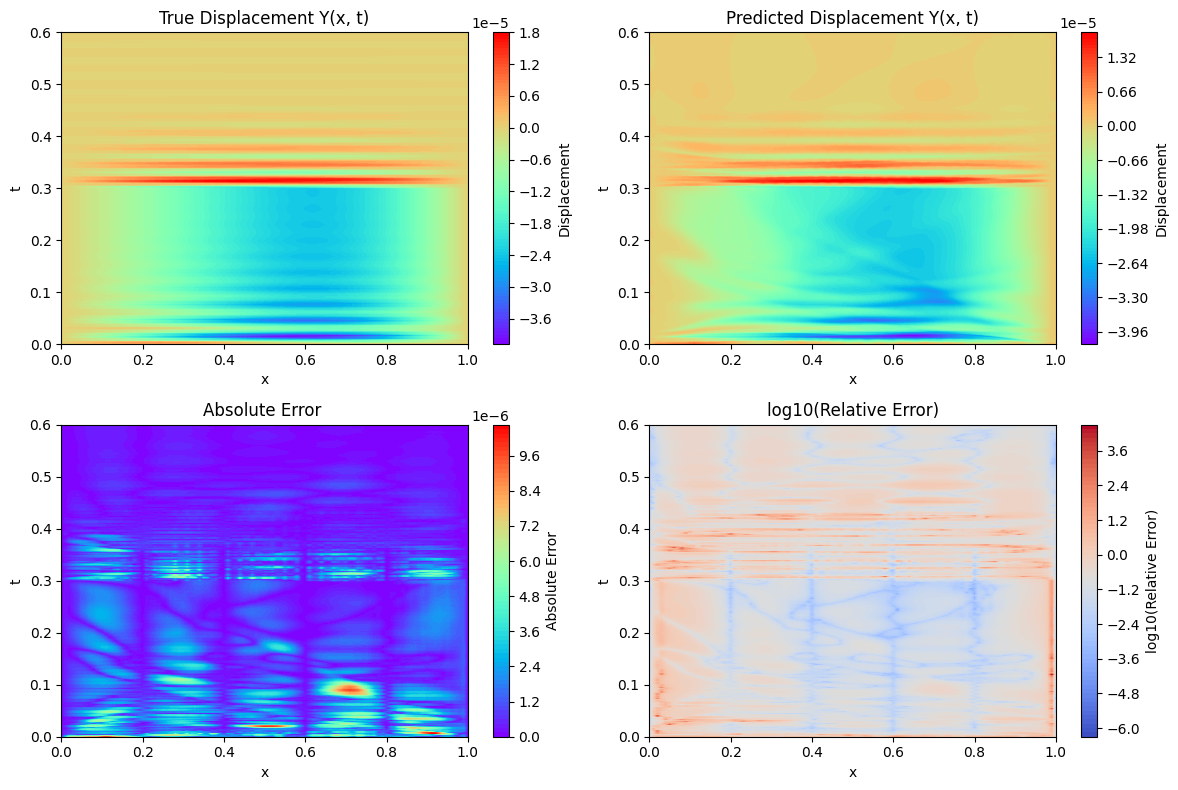

Final Full Grid MSE Loss: 1.378568


In [5]:
 
model.eval()
with torch.no_grad():
    U_predicted_grid_plot = 0.00001*model(x_full_tensor, edge_index_full).cpu().numpy().reshape(num_t_full, num_x_full)
U_full_grid_true=10**-5*U_full_grid_true
y_error = U_predicted_grid_plot - U_full_grid_true
epsilon = 1e-6 
R_y_error = np.abs((U_predicted_grid_plot - U_full_grid_true) / (U_full_grid_true + epsilon)) # 或者更复杂的处理

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.contourf(X_full_grid, T_full_grid, U_full_grid_true, levels=100, cmap='rainbow')
plt.colorbar(label='Displacement')
plt.xlabel('x')
plt.ylabel('t')
plt.title('True Displacement Y(x, t)')

plt.subplot(2, 2, 2)
plt.contourf(X_full_grid, T_full_grid, U_predicted_grid_plot, levels=100, cmap='rainbow')
plt.colorbar(label='Displacement')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Predicted Displacement Y(x, t)')

plt.subplot(2, 2, 3)
plt.contourf(X_full_grid, T_full_grid, np.abs(y_error), levels=100, cmap='rainbow') 
plt.colorbar(label='Absolute Error')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Absolute Error ')

log_R_y_error = np.log10(np.clip(R_y_error, a_min=1e-10, a_max=None)) 
plt.subplot(2, 2, 4)
plt.contourf(X_full_grid, T_full_grid, log_R_y_error, levels=100, cmap='coolwarm')
plt.colorbar(label='log10(Relative Error)')
plt.xlabel('x')
plt.ylabel('t')
plt.title('log10(Relative Error)')
plt.tight_layout()
plt.savefig("数据驱动 响应预测.png", dpi=300)
plt.show()

final_full_mse = criterion(torch.tensor(U_predicted_grid_plot).to(device), y_full_tensor.reshape(num_t_full, num_x_full)).item()
print(f"Final Full Grid MSE Loss: {final_full_mse:.6f}")


/tmp/ipykernel_4634/2237793164.py:47: RuntimeWarning: divide by zero encountered in divide
  relative_error_1_4 = np.abs(y_true_1_4 - y_pred_1_4) / np.abs(y_true_1_4)
/tmp/ipykernel_4634/2237793164.py:48: RuntimeWarning: divide by zero encountered in divide
  relative_error_1_2 = np.abs(y_true_1_2 - y_pred_1_2) / np.abs(y_true_1_2)
/tmp/ipykernel_4634/2237793164.py:49: RuntimeWarning: divide by zero encountered in divide
  relative_error_3_4 = np.abs(y_true_3_4 - y_pred_3_4) / np.abs(y_true_3_4)
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' 

已将 t、y_true 和 y_pred 保存到 response_data.mat


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

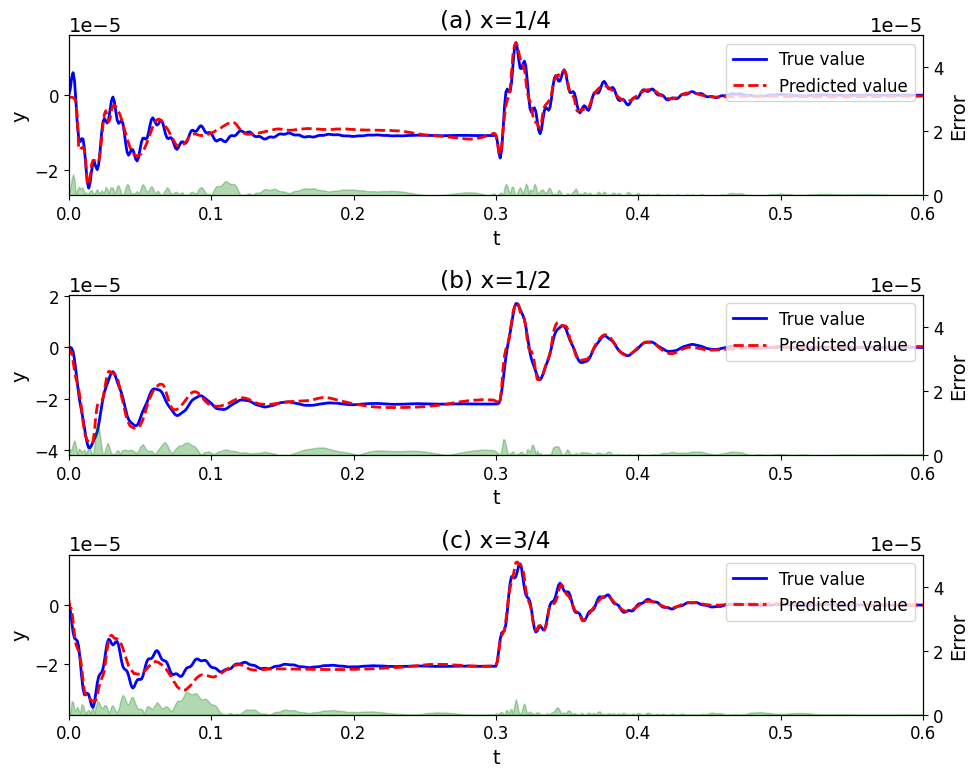

In [13]:
import scipy.io as sio

x_indices = [26, 51, 76] 
t_data = T_full_grid[:, 0:1] 

y_true_reshaped= U_full_grid_true

y_pre_reshaped =U_predicted_grid_plot

y_true_1_4 = y_true_reshaped[:, 25:26]
y_true_1_2 = y_true_reshaped[:, 50:51]
y_true_3_4 = y_true_reshaped[:, 75:76]
y_pred_1_4 = y_pre_reshaped[:, 25:26]
y_pred_1_2 = y_pre_reshaped[:, 50:51]
y_pred_3_4 = y_pre_reshaped[:, 75:76]



TTT=t_data[:, 0]

mat_dict = {
    't':               TTT,
    'G-y_true_1_4':     y_true_1_4,
    'G-y_pred_1_4':     y_pred_1_4,
    'G-y_true_1_2':     y_true_1_2,
    'G-y_pred_1_2':     y_pred_1_2,
    'G-y_true_3_4':     y_true_3_4,
    'G-y_pred_3_4':     y_pred_3_4,
   
}

sio.savemat('GCN_response_data.mat', mat_dict, do_compression=True)

print("已将 t、y_true 和 y_pred 保存到 response_data.mat")


relative_error_1_4 = np.abs(y_true_1_4 - y_pred_1_4) / np.abs(y_true_1_4)
relative_error_1_2 = np.abs(y_true_1_2 - y_pred_1_2) / np.abs(y_true_1_2)
relative_error_3_4 = np.abs(y_true_3_4 - y_pred_3_4) / np.abs(y_true_3_4)
Error_1_4 = np.abs(y_true_1_4 - y_pred_1_4) 
Error_1_2 = np.abs(y_true_1_2 - y_pred_1_2)
Error_3_4 = np.abs(y_true_3_4 - y_pred_3_4)



plt.figure(figsize=(10, 8))
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14 
epsilon = 1e-10


plt.subplot(3, 1, 1)
ax1 = plt.gca() 
ax2 = ax1.twinx() 

ax1.plot(t_data[:, 0], y_true_1_4, label='True value', color='blue', linestyle='-', linewidth=2)
ax1.plot(t_data[:, 0], y_pred_1_4, label='Predicted value', color='red', linestyle='--', linewidth=2)


ax2.fill_between(t_data[:, 0], 0, Error_1_4.flatten(), color='green', alpha=0.3)

ax1.set_xlabel('t')
ax1.set_ylabel('y')
ax2.set_ylabel('Error')
ax1.set_xlim(0, 0.6)
ax2.set_ylim(0, 5e-5)

ax1.tick_params(axis='x', labelsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax2.tick_params(axis='y', labelsize=12)

ax1.set_title('(a) x=1/4')
ax1.legend(loc='upper right', fontsize=12)


plt.subplot(3, 1, 2)
ax1 = plt.gca()  
ax2 = ax1.twinx()  



ax1.plot(t_data[:, 0], y_true_1_2, label='True value', color='blue', linestyle='-', linewidth=2)
ax1.plot(t_data[:, 0], y_pred_1_2, label='Predicted value', color='red', linestyle='--', linewidth=2)


log_relative_error_1_2 = np.log(np.abs(relative_error_1_2.flatten()) + epsilon)

ax2.fill_between(t_data[:, 0], 0, Error_1_2.flatten(), color='green', alpha=0.3)

ax1.set_xlabel('t')
ax1.set_ylabel('y')
ax2.set_ylabel('Error')
ax1.set_xlim(0, 0.6)
ax2.set_ylim(0, 5e-5)


ax1.tick_params(axis='x', labelsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax2.tick_params(axis='y', labelsize=12)

ax1.set_title('(b) x=1/2')
ax1.legend(loc='upper right', fontsize=12)


plt.subplot(3, 1, 3)
ax1 = plt.gca()  
ax2 = ax1.twinx()  

ax1.plot(t_data[:, 0], y_true_3_4, label='True value', color='blue', linestyle='-', linewidth=2)
ax1.plot(t_data[:, 0], y_pred_3_4, label='Predicted value', color='red', linestyle='--', linewidth=2)


log_relative_error_3_4 = np.log(np.abs(relative_error_3_4.flatten()) + epsilon)



ax2.fill_between(t_data[:, 0], 0, Error_3_4.flatten(), color='green', alpha=0.3)

ax1.set_xlabel('t')
ax1.set_ylabel('y')
ax2.set_ylabel('Error')
ax1.set_xlim(0, 0.6)
ax2.set_ylim(0, 5e-5)


ax1.tick_params(axis='x', labelsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax2.tick_params(axis='y', labelsize=12)

ax1.set_title('(c) x=3/4')
ax1.legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.savefig("响应对比.png", dpi=300)
plt.show()


Pearson correlation coefficient: 0.991070786412054
决定系数 (R²): 0.9822213036794072


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

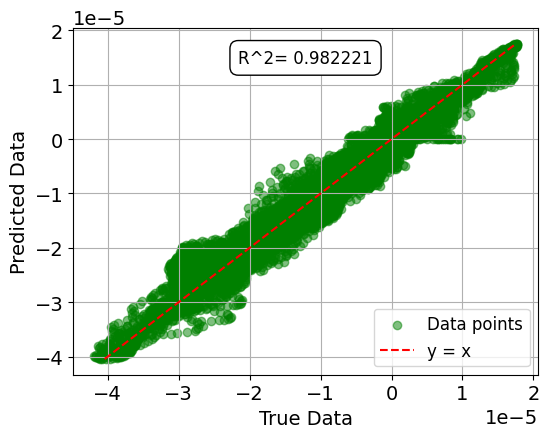

In [6]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14 


plt.figure(figsize=(6, 4.5))

plt.scatter(U_predicted_grid_plot , U_full_grid_true, color="green", alpha=0.5, label="Data points")


y2_data =U_full_grid_true.flatten()
Y_PRE = U_predicted_grid_plot.flatten()

correlation, _ = pearsonr(y2_data, Y_PRE)
print(f"Pearson correlation coefficient: {correlation}")
r_squared = correlation ** 2
print(f"决定系数 (R²): {r_squared}")

plt.text(0.5, 0.9, f"R^2= {r_squared:.6f}", fontsize=12, ha='center', 
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))


plt.plot([min(y2_data), max(y2_data)], [min(y2_data), max(y2_data)], color="red", linestyle="--", label="y = x")


plt.xlabel("True Data")
plt.ylabel("Predicted Data")
plt.title("")
plt.xticks(fontsize=14)  
plt.yticks(fontsize=14) 
plt.legend(loc='lower right', fontsize=12)  #
plt.grid()


plt.savefig("预测精度.png", dpi=300)

In [8]:

diff = U_predicted_grid_plot.flatten() - U_full_grid_true.flatten()
mse = np.mean(diff ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(diff))

print(f"\nRMSE (Root Mean Squared Error): {rmse:.10f}")
print(f"MAE (Mean Absolute Error): {mae:.10f}")


RMSE (Root Mean Squared Error): 0.0000012738
MAE (Mean Absolute Error): 0.0000007896
